In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import time
import ast
from collections import Counter
import warnings
import os
import re

In [3]:
from tools import extract_hours, visualize_dag, pert_sample, draw_random_durations, compute_times, find_critical_path, simulation

In [4]:
sns.set_theme(palette='tab10')

## Dataset

In [5]:
project_name='C2019-05_Fuel_Tank_Filter'
file_path='dataset/C2019-05 Fuel Tank Filter.xlsx'
Nca=10 # Number of control accounts (tracking points)

### Baseline Schedule

In [6]:
# Read the baseline schedule
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    df=pd.read_excel(file_path, sheet_name='Baseline Schedule',skiprows=1,index_col=0,usecols='A:N')
df.drop(0,axis=0,inplace=True) # drop the first row
df.drop(df[df['Successors'].isna() & df['Predecessors'].isna()].index,axis=0,inplace=True) # drop the rows with NaN successors and predecessors that not correspond to any activity
df['DurationH']=df['Duration'].apply(lambda x: extract_hours(x)) # extract the duration in hours
df_project=df[['Name', 'Successors', 'DurationH', 'Total Cost']].copy()
df_project.columns=['Name', 'Successors', 'Duration', 'TotalCost']

### Stochastic Schedule Modeling

In [7]:
# Risk analysis

# Assume a skewed left distribution for the risk
# relative to baseline duration
OPT=0.8 # Optimistic
MP=1.1 # Most probable
PE=1.2 # Pessimistic

# Compute the optimistic, most probable, and pessimistic durations in hours
df_project['Optimistic']=df_project['Duration']*OPT
df_project['MostProbable']=df_project['Duration']*MP
df_project['Pessimistic']=df_project['Duration']*PE

### Activity on Node (AON) Network

In [20]:
# Build the Activity on Node (AON) network
# The activity‐on‐node (AON) network is modeled as a Networkx directed acyclic 
Go=nx.DiGraph()
for i in df_project.index:
    mean_d=(df_project.loc[i,'Optimistic']+4*df_project.loc[i,'MostProbable']+df_project.loc[i,'Pessimistic'])/6
    Go.add_node(i,
               planned_value = df_project.loc[i,'TotalCost'], # The planned value
               duration0=df_project.loc[i,'Duration'], # The baseline duration
               optimistic = df_project.loc[i,'Optimistic'], # The optimistic duration
               pessimistic = df_project.loc[i,'Pessimistic'], # The pessimistic duration
               mostlikely = df_project.loc[i,'MostProbable'], # The most likely duration
               mean_duration=mean_d) # The mean duration
    if not pd.isna(df_project.loc[i,'Successors']):
        for s in df_project.loc[i,'Successors'].split(";"):
            Go.add_edge(i,int(s[2:]),type=s[:2])
print(f'AON graph with {Go.number_of_nodes()} nodes and {Go.number_of_edges()} edges')
print('Is a directed aclyclic grapk',nx.is_directed_acyclic_graph(Go))  

AON graph with 15 nodes and 23 edges
Is a directed aclyclic grapk True


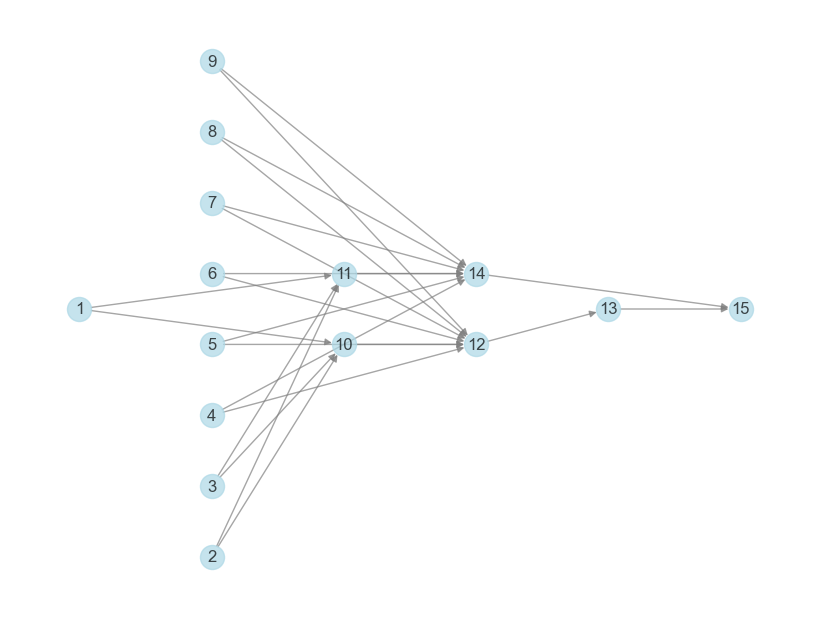

In [21]:
# Visualize the AON network
visualize_dag(Go)

In [45]:
# Deterministic PERT duration of the project
_,ft = compute_times(Go,time='duration0')
print(f'The project duration is {np.max([f for f in ft.values()]):.2f} hours')
_,ft = compute_times(Go,time='mean_duration')
print(f'The project mean duration is {np.max([f for f in ft.values()]):.2f} hours')
_,ft = compute_times(Go,time='optimistic')
print(f'The project optimistic duration is {np.max([f for f in ft.values()]):.2f} hours')
_,ft = compute_times(Go,time='pessimistic')
print(f'The project pessimistic duration is {np.max([f for f in ft.values()]):.2f} hours')

The project duration is 4088.00 hours
The project mean duration is 4360.53 hours
The project optimistic duration is 3270.40 hours
The project pessimistic duration is 4905.60 hours


## Initial Analysis

In [10]:
# PERT deterministic duration of the project
PERT_duration=np.max([t for t in compute_times(Go,time='mean_duration')[1].values()])
print(f'The PERT deterministic duration of the project is {PERT_duration:.2f} hours')

The PERT deterministic duration of the project is 4360.53 hours


### Simulation of all tracking points

In [12]:
Ns=1000 # Number of simulation runs

In [13]:
# Simulations 
start_time = time.time()
for tp in range(Nca+1):
    
    if tp==0: # Baseline schedule
        print('Simulation for the baseline schedule ...')
        simulation(Go.copy(),project_name,experiment='tp0_ev0',control=None,Nruns=Ns)
    else:
        # Read the control account data
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            df=pd.read_excel(file_path, sheet_name='TP'+str(tp),skiprows=3,index_col=0)
        ev_percent=df.loc[0,'Percentage Completed'] # Read the EV%
        dfc=df.loc[df.index.intersection(Go.nodes()),['Actual Duration', 'Actual Cost','Percentage Completed', 'Earned Value (EV)', 'Planned Value (PV)']].copy()
        dfc['Actual Duration']=dfc['Actual Duration'].apply(lambda x: extract_hours(x)) # extract the duration in hours
        dfc.columns=['ActualDuration', 'ActualCost', 'PercentageCompleted', 'EarnedValue', 'PlannedValue'] # rename the columns

        # Simulations from TP
        print('Simulation for TP'+str(tp)+' ...')
        simulation(Go.copy(),project_name,experiment='tp'+str(tp)+"_ev" +str(round(ev_percent,4)),control=dfc,Nruns=Ns)
print(f"Monte Carlo Simulation took {time.time() - start_time} seconds to run {(Nca+1)*Ns} samples")


Simulation for the baseline schedule ...
Simulation for TP1 ...
Simulation for TP2 ...
Simulation for TP3 ...
Simulation for TP4 ...
Simulation for TP5 ...
Simulation for TP6 ...
Simulation for TP7 ...
Simulation for TP8 ...
Simulation for TP9 ...
Simulation for TP10 ...
Monte Carlo Simulation took 29.24297833442688 seconds to run 11000 samples


### Criticality Index

In [15]:
# Read the simulation files !!!!!!!
siml=[file for file in os.listdir(os.path.join("./data/",project_name)) if (f"simulation_{project_name}_tp") in file]
siml=[(int(re.search(r'tp(\d+)', file).group(1)), re.search(r'ev([\d.]+)', file).group(1)[:-1],file) for file in siml] 
siml=sorted(siml,key=lambda x: x[0])

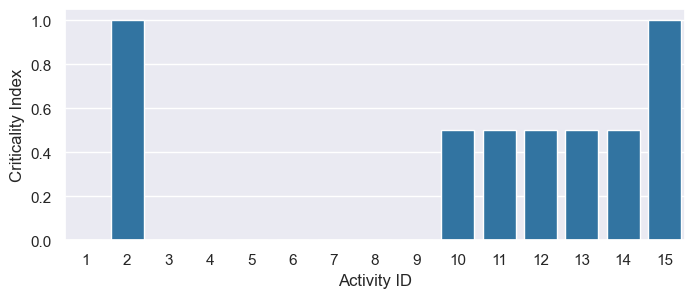

In [16]:
# Criticality index of activities
data=siml[0] # Baseline schedule
df_sim=pd.read_csv('./data/'+project_name+'/'+data[2])
N=df_sim.shape[0] # Number of samples
criticality_index={n:0 for n in Go.nodes()}
for i,v in Counter(df_sim['critical_path'].apply(lambda x: ast.literal_eval(x)).sum()).items():
    criticality_index[i]=v/N
g=sns.barplot(x=list(criticality_index.keys()), y=list(criticality_index.values()))
g.set_xlabel('Activity ID')
g.set_ylabel('Criticality Index')
g.figure.set_size_inches(8,3)

### Histograms of Actual Durations for all Tracking Points

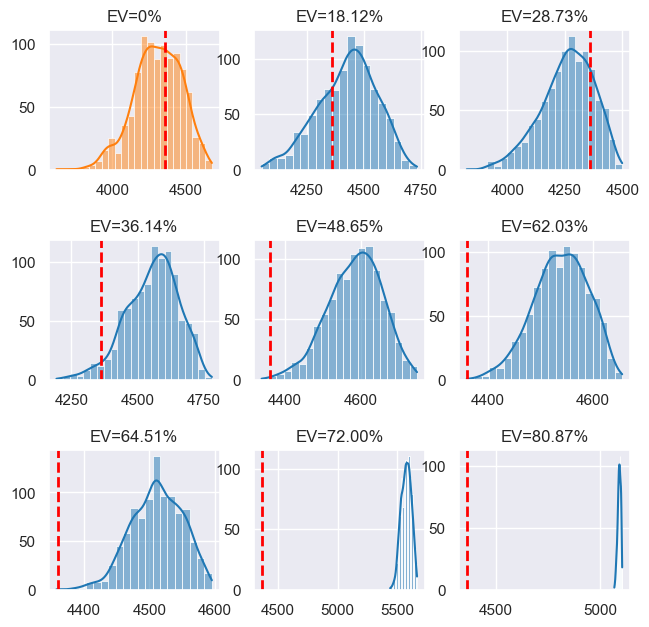

In [17]:
# Plot the histograms
Nr=Nca//3+1
Nc=3
plt.figure(figsize=(Nc*2.5,Nr*2.5))

# Remove the TP7 because it is the same EV as the TP8
siml=[sim for sim in siml if sim[0]!=7]

data=siml[0] # Baseline schedule
df_sim=pd.read_csv('./data/'+project_name+'/'+data[2])
tp = data[0]
ev = data[1]
plt.subplot(Nr,Nc,1)
g=sns.histplot(df_sim['actual_duration'],kde=True,color=sns.color_palette("tab10")[1])
plt.axvline(x=df_sim.loc[0,'baseline_duration'], color='red', linestyle='--', linewidth=2,label='Baseline duration')
g.set_xlabel('')
g.set_ylabel('')
g.set_title("EV=0%")

for i,data in enumerate(siml):
    if (i>0) and (i<len(siml)-1): # skip the baseline schedule and the last control account
        df_sim=pd.read_csv('./data/'+project_name+'/'+data[2])
        tp = data[0]
        ev = data[1]
        plt.subplot(Nr,Nc, i+1)
        g=sns.histplot(df_sim['actual_duration'],kde=True)
        plt.axvline(x=df_sim.loc[0,'baseline_duration'], color='red', linestyle='--', linewidth=2,label='Baseline duration')
        g.set_xlabel('')
        g.set_ylabel('')
        g.set_title(f"EV={float(ev)*100:0.2f}%")

plt.subplots_adjust(hspace=0.5)

## Monte Carlo Simulation for the Tracking Point EV=18%

In [18]:
tp=1 # tracking point
Ns=25000 # Number of simulation runs
start_time = time.time()
# Read the control account data
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    df=pd.read_excel(file_path, sheet_name='TP'+str(tp),skiprows=3,index_col=0)
ev_percent=df.loc[0,'Percentage Completed'] # Read the EV%
dfc=df.loc[df.index.intersection(Go.nodes()),['Actual Duration', 'Actual Cost','Percentage Completed', 'Earned Value (EV)', 'Planned Value (PV)']].copy()
dfc['Actual Duration']=dfc['Actual Duration'].apply(lambda x: extract_hours(x)) # extract the duration in hours
dfc.columns=['ActualDuration', 'ActualCost', 'PercentageCompleted', 'EarnedValue', 'PlannedValue'] # rename the columns
# Simulations from TP
print('Simulation for TP'+str(tp)+' ...')
simulation(Go.copy(),project_name='C201905_counterfactuals',experiment="_ev" +str(round(ev_percent,4)),control=dfc,Nruns=Ns)
print(f"Monte Carlo Simulation took {time.time() - start_time} seconds to run {Ns} samples")


Simulation for TP1 ...
Monte Carlo Simulation took 67.36309385299683 seconds to run 25000 samples
